# Footbench — Bradley-Terry model diagnostics

Convergence and sampling diagnostics for the hierarchical Bayesian Bradley-Terry model
(`footbench/footbench/bradley_terry.py`), run with **ArviZ**. This notebook does **not**
report results — it only assesses how reliably the MCMC ran, per track
(`overall`, `soundness`, `priors`), by reading the persisted posterior traces from
`footbench/artifacts/bradley_terry/*.nc`.

What to look for:

- **R-hat** ≤ 1.01 (chains converged to the same distribution).
- **ESS** (bulk & tail) comfortably in the hundreds-to-thousands (enough effective samples).
- **Divergences** = 0 (no pathological geometry the sampler couldn't explore).
- **BFMI** ≳ 0.3 (the momentum resampling is efficient; low values flag a hard posterior).


In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from footbench import bradley_terry as bt
from footbench.config import load_config

cfg = load_config()
TRACKS = ["overall", "soundness", "priors"]
traces = {t: az.from_netcdf(str(bt.trace_path(cfg, t))) for t in TRACKS}

# variable groups for the plots
BETA = ["beta"]
JUDGE_EFFECTS = ["kappa", "gamma", "delta"]
HYPER = ["mu_gamma", "mu_delta", "sigma_kappa", "sigma_gamma", "sigma_delta"]

{t: dict(traces[t].posterior.sizes) for t in TRACKS}


{'overall': {'chain': 4, 'draw': 2000, 'judge': 4, 'model': 12},
 'soundness': {'chain': 4, 'draw': 2000, 'judge': 4, 'model': 12},
 'priors': {'chain': 4, 'draw': 2000, 'judge': 4, 'model': 12}}

## Convergence at a glance

One row per track. All three tracks should show `max_r_hat` ≈ 1.00, ESS in the thousands,
zero divergences, and BFMI well above 0.3. Anything outside those bands is flagged.


In [2]:
rows = []
for t in TRACKS:
    idata = traces[t]
    s = az.summary(idata, ci_prob=0.94)
    rhat = s["r_hat"].astype(float)
    ess_bulk = s["ess_bulk"].astype(float)
    ess_tail = s["ess_tail"].astype(float)
    energy = idata.sample_stats["energy"].to_numpy()
    bfmi = np.array([np.sum(np.diff(e) ** 2) / np.sum((e - e.mean()) ** 2) for e in energy])
    n_div = int(idata.sample_stats["diverging"].to_numpy().sum())
    rows.append(
        {
            "track": t,
            "n_params": int(s.shape[0]),
            "max_r_hat": round(float(rhat.max()), 4),
            "min_ess_bulk": round(float(ess_bulk.min()), 0),
            "min_ess_tail": round(float(ess_tail.min()), 0),
            "divergences": n_div,
            "min_bfmi": round(float(bfmi.min()), 3),
            "ok": bool(
                rhat.max() <= 1.01 and ess_bulk.min() >= 400 and n_div == 0 and bfmi.min() >= 0.3
            ),
        }
    )
flags = pl.DataFrame(rows)
flags


track,n_params,max_r_hat,min_ess_bulk,min_ess_tail,divergences,min_bfmi,ok
str,i64,f64,f64,f64,i64,f64,bool
"""overall""",41,1.0,1467.0,2218.0,0,0.684,true
"""soundness""",41,1.0,1779.0,2664.0,0,0.654,true
"""priors""",41,1.0,1600.0,2454.0,0,0.747,true


## Per-parameter summary

ArviZ's full table per track: posterior mean/sd, 94% interval, ESS (bulk/tail), MCSE, and
R-hat for every parameter (model strengths `beta`, judge effects `kappa`/`gamma`/`delta`,
and the population hyperparameters).


In [3]:
for t in TRACKS:
    display(Markdown(f"**Track: `{t}`**"))
    display(az.summary(traces[t], ci_prob=0.94))


**Track: `overall`**

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z_kappa[claude-opus-4-8],1.03,0.38,0.4,1.8,3720,4408,1.00,0.0062,0.005
z_kappa[deepseek-v4-pro],0.48,0.37,-0.26,1.2,2497,3181,1.00,0.0077,0.0072
z_kappa[gemini-3.5-flash],1.51,0.46,0.79,2.5,4021,4187,1.00,0.0074,0.0061
z_kappa[gpt-5.5],0.79,0.36,0.16,1.5,3457,4023,1.00,0.0062,0.0054
mu_gamma,0.84,0.307,0.2,1.3,3777,4790,1.00,0.005,0.0041
z_gamma[claude-opus-4-8],-0.33,0.62,-1.6,0.74,4416,5213,1.00,0.0094,0.007
z_gamma[deepseek-v4-pro],1.33,0.6,0.27,2.5,5677,5462,1.00,0.008,0.0061
z_gamma[gemini-3.5-flash],1.12,0.61,-0.015,2.3,6343,5461,1.00,0.0077,0.0058
z_gamma[gpt-5.5],-0.25,0.62,-1.5,0.83,4384,5038,1.00,0.0094,0.0073
mu_delta,0.253,0.332,-0.39,0.86,4716,5181,1.00,0.0048,0.0035


**Track: `soundness`**

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z_kappa[claude-opus-4-8],1.43,0.43,0.73,2.3,3593,4371,1.00,0.0073,0.0058
z_kappa[deepseek-v4-pro],0.47,0.34,-0.18,1.1,2763,3562,1.00,0.0066,0.0052
z_kappa[gemini-3.5-flash],1.11,0.36,0.53,1.9,3119,3826,1.00,0.0067,0.0058
z_kappa[gpt-5.5],1.29,0.4,0.61,2.1,2923,3587,1.00,0.0076,0.0058
mu_gamma,1.27,0.41,0.39,1.9,2803,4193,1.00,0.0078,0.0057
z_gamma[claude-opus-4-8],0.37,0.77,-1.2,1.7,5747,4698,1.00,0.01,0.0081
z_gamma[deepseek-v4-pro],1.34,0.79,-0.34,2.7,3988,3313,1.00,0.013,0.012
z_gamma[gemini-3.5-flash],0.66,0.77,-0.95,2,4228,4208,1.00,0.012,0.01
z_gamma[gpt-5.5],0.25,0.78,-1.4,1.6,5694,5132,1.00,0.01,0.0079
mu_delta,0.39,0.369,-0.34,1.1,4816,5433,1.00,0.0053,0.0038


**Track: `priors`**

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z_kappa[claude-opus-4-8],2.1,0.49,1.3,3.1,4288,4734,1.00,0.0076,0.0058
z_kappa[deepseek-v4-pro],0.6,0.267,0.13,1.1,2833,3728,1.00,0.005,0.0039
z_kappa[gemini-3.5-flash],0.98,0.303,0.47,1.6,3407,4041,1.00,0.0053,0.0042
z_kappa[gpt-5.5],1.19,0.346,0.62,1.9,3962,4229,1.00,0.0056,0.0044
mu_gamma,0.846,0.279,0.25,1.3,4778,3978,1.00,0.0042,0.0037
z_gamma[claude-opus-4-8],0.04,0.87,-1.6,1.7,9216,6209,1.00,0.0091,0.0066
z_gamma[deepseek-v4-pro],0.71,0.86,-1,2.2,6262,5782,1.00,0.011,0.0086
z_gamma[gemini-3.5-flash],0.47,0.85,-1.2,2,6626,5898,1.00,0.011,0.008
z_gamma[gpt-5.5],-0.18,0.86,-1.8,1.4,9138,6034,1.00,0.009,0.007
mu_delta,0.089,0.359,-0.6,0.76,6034,5697,1.00,0.0046,0.0034


## Trace plots

For each chain, the left column is the marginal posterior (chains should overlap) and the
right column is the sampled value over iterations (should look like stationary white noise —
"fuzzy caterpillars" — with no trends, sticking, or separated chains). Shown for the model
strengths `beta` and the population hyperparameters.


### `overall` — strengths (beta)

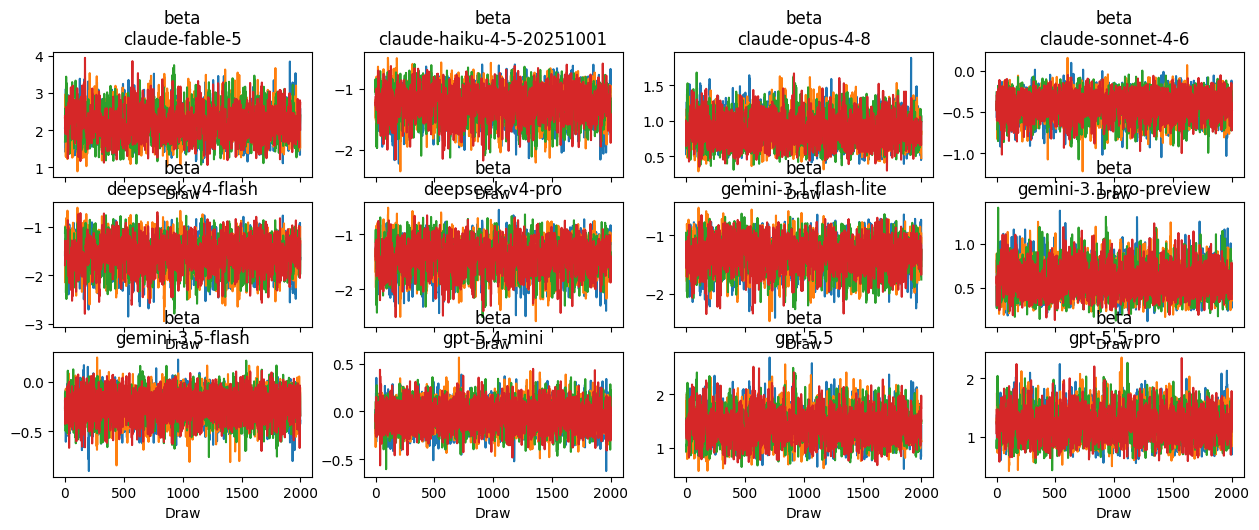

### `overall` — hyperparameters

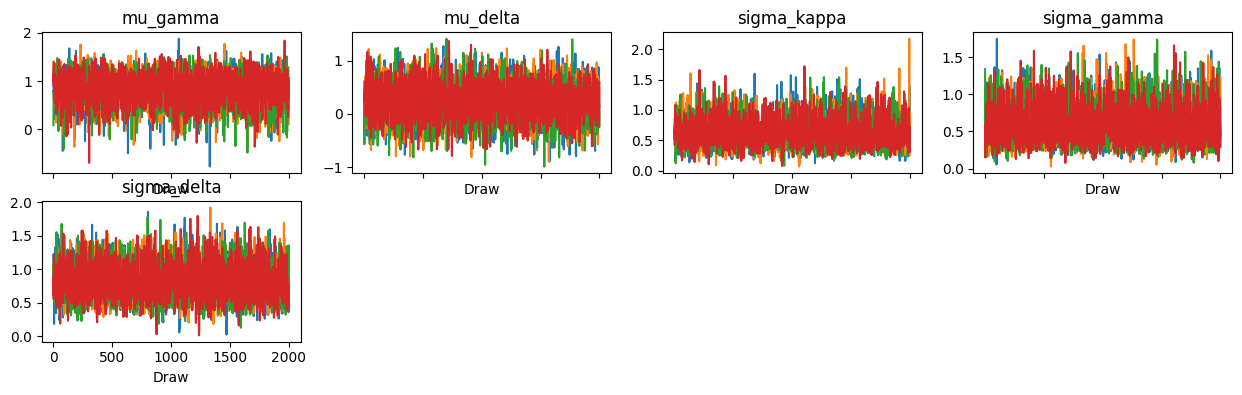

### `soundness` — strengths (beta)

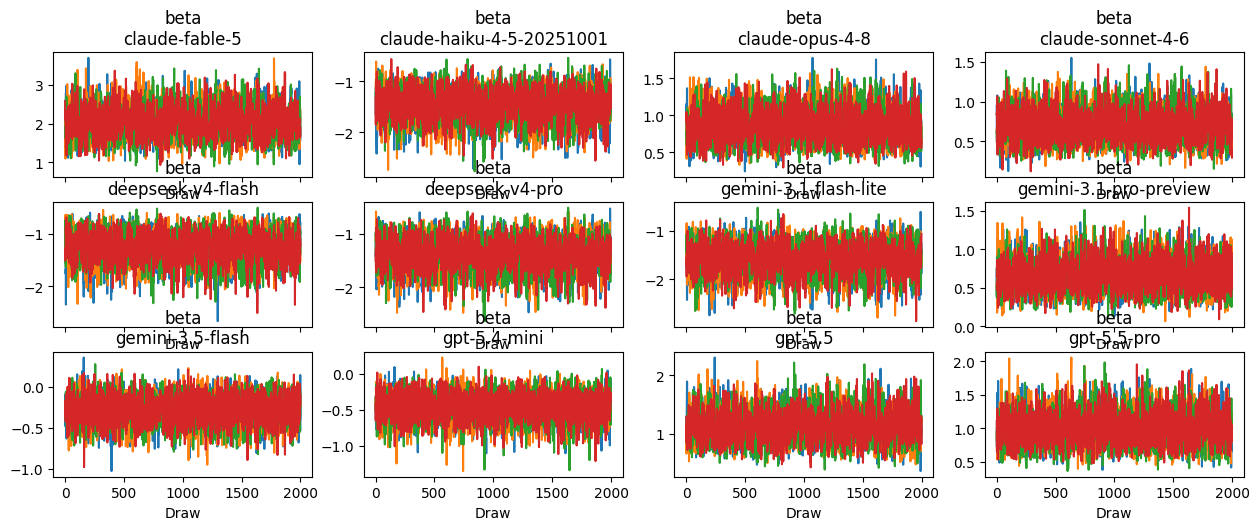

### `soundness` — hyperparameters

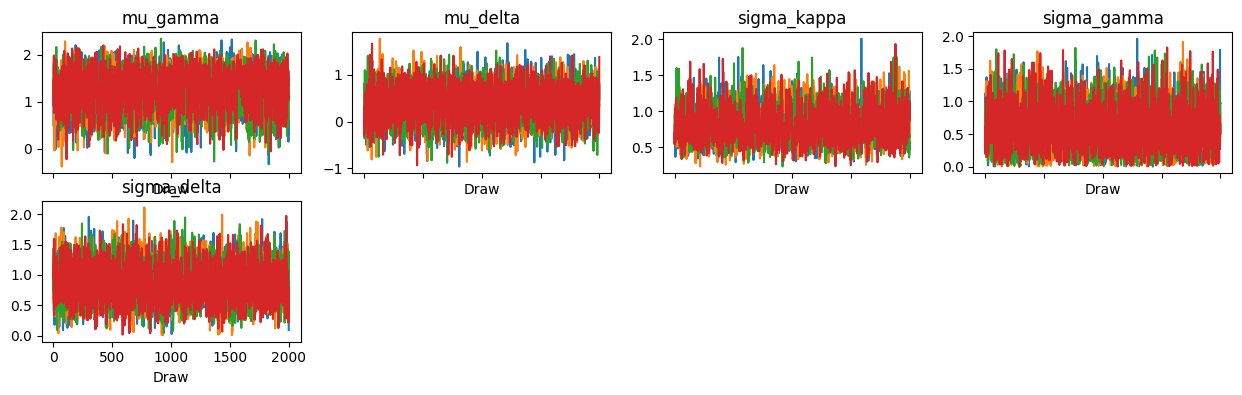

### `priors` — strengths (beta)

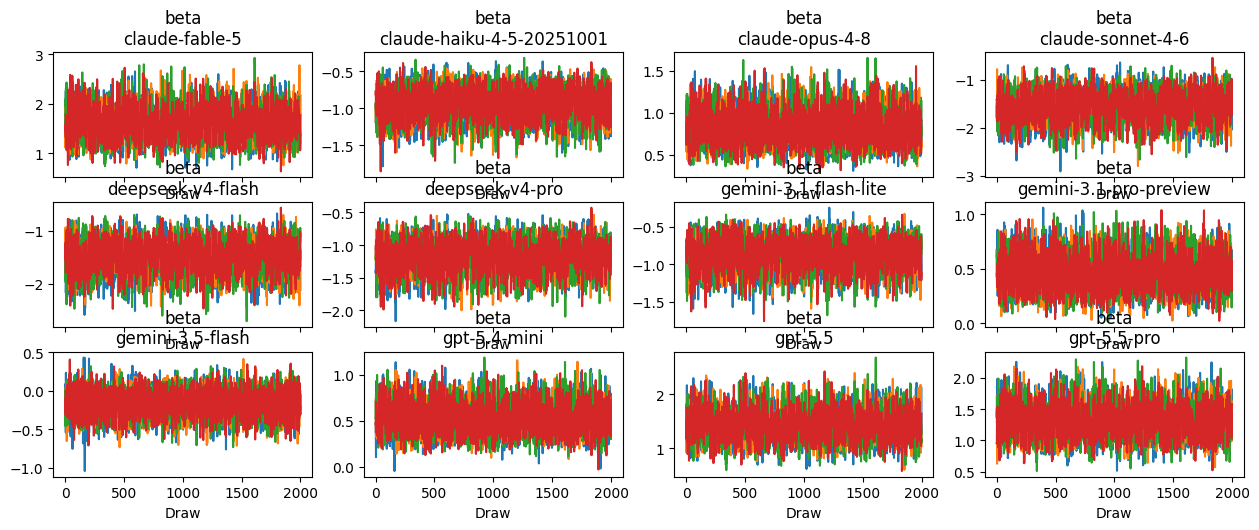

### `priors` — hyperparameters

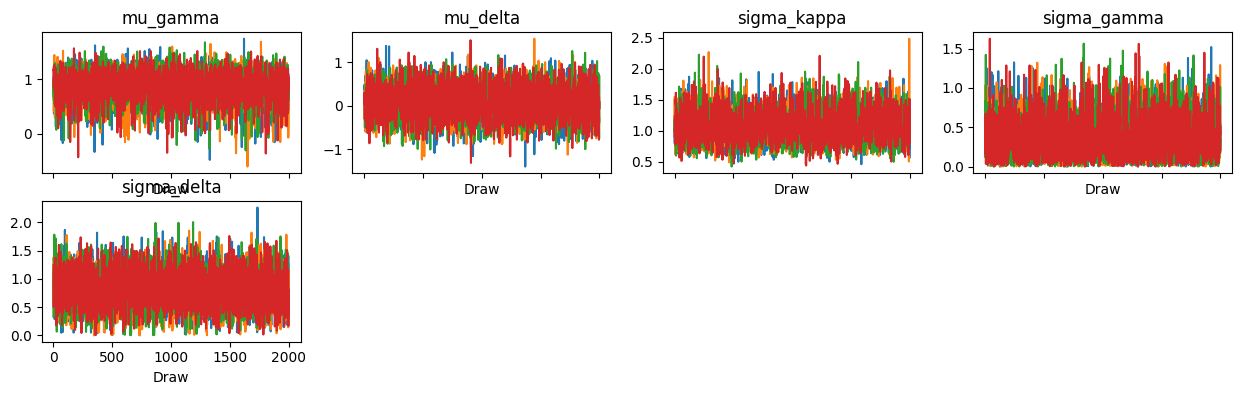

In [4]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — strengths (beta)"))
    az.plot_trace(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()
    display(Markdown(f"### `{t}` — hyperparameters"))
    az.plot_trace(traces[t], var_names=HYPER, backend="matplotlib")
    plt.show()


## Rank plots

A more sensitive convergence check than trace plots: across all chains the rank-normalized
draws should be ~uniform (flat histograms / even bars). Systematic departures indicate the
chains are not sampling the same distribution.


### `overall` — rank plots (beta)

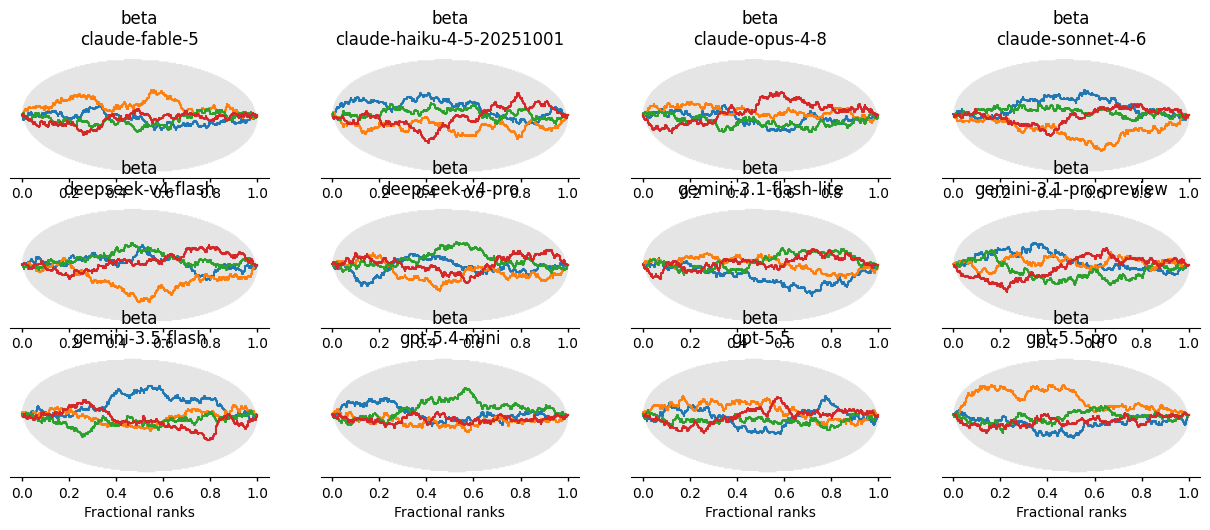

### `soundness` — rank plots (beta)

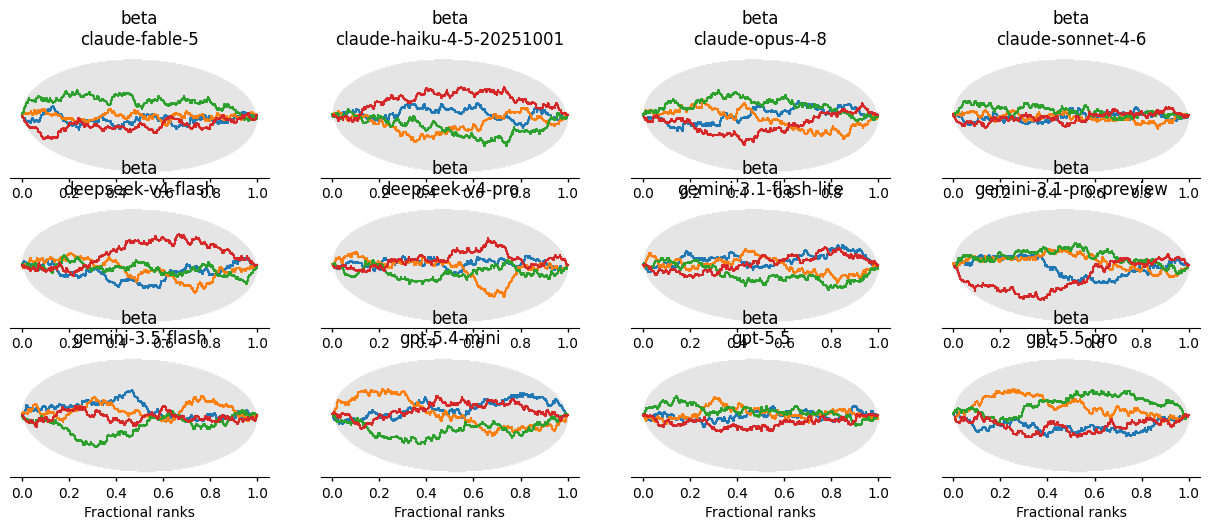

### `priors` — rank plots (beta)

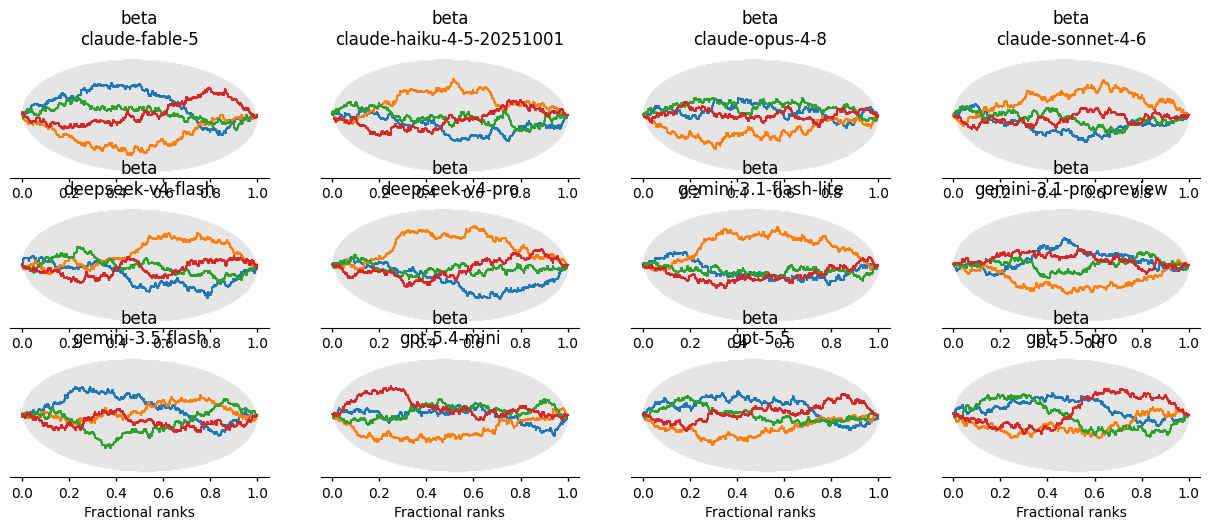

In [5]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — rank plots (beta)"))
    az.plot_rank(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()


## Energy (BFMI)

The marginal energy and energy-transition distributions should overlap closely. Poor overlap
(low BFMI) means the sampler struggles to explore the posterior's tails — a reason to distrust
the effective sample size.


### `overall` — energy

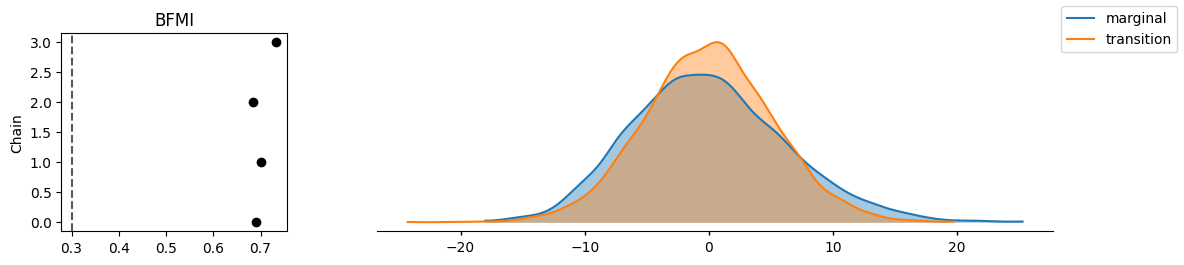

### `soundness` — energy

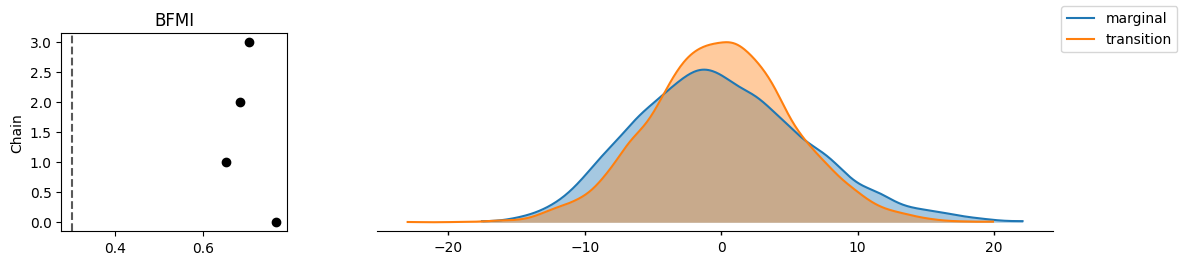

### `priors` — energy

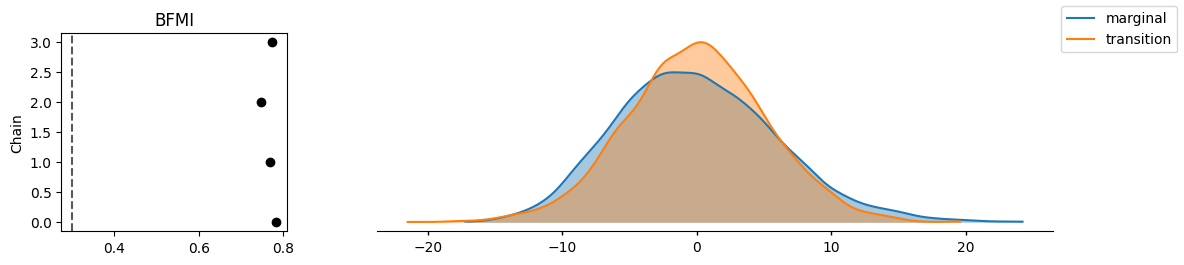

In [6]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — energy"))
    az.plot_energy(traces[t], backend="matplotlib")
    plt.show()


## Forest plots

Posterior intervals side by side. `beta` is each model's latent strength (sum-to-zero scale);
the judge effects show per-judge discrimination (`kappa`), position/slot-A bias (`gamma`), and
self-family preference (`delta`). With only four judges, the judge-level estimates are wide —
read them as directional.


### `overall` — strengths (beta)

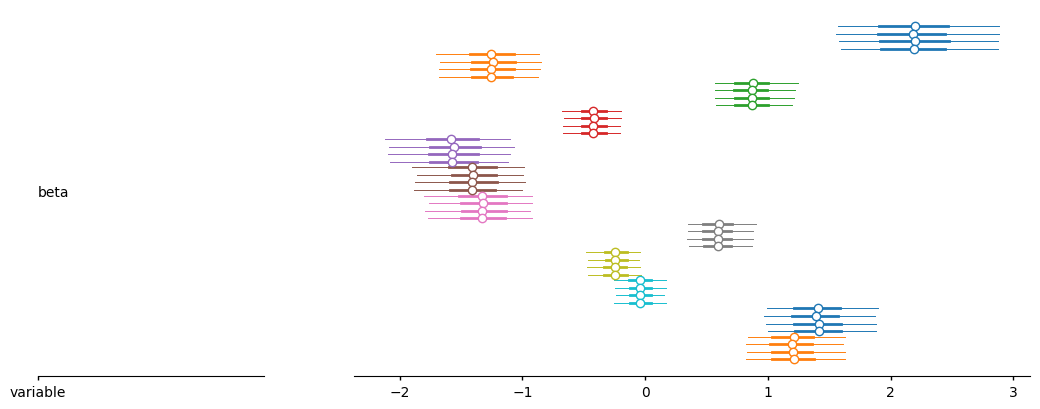

### `overall` — judge effects

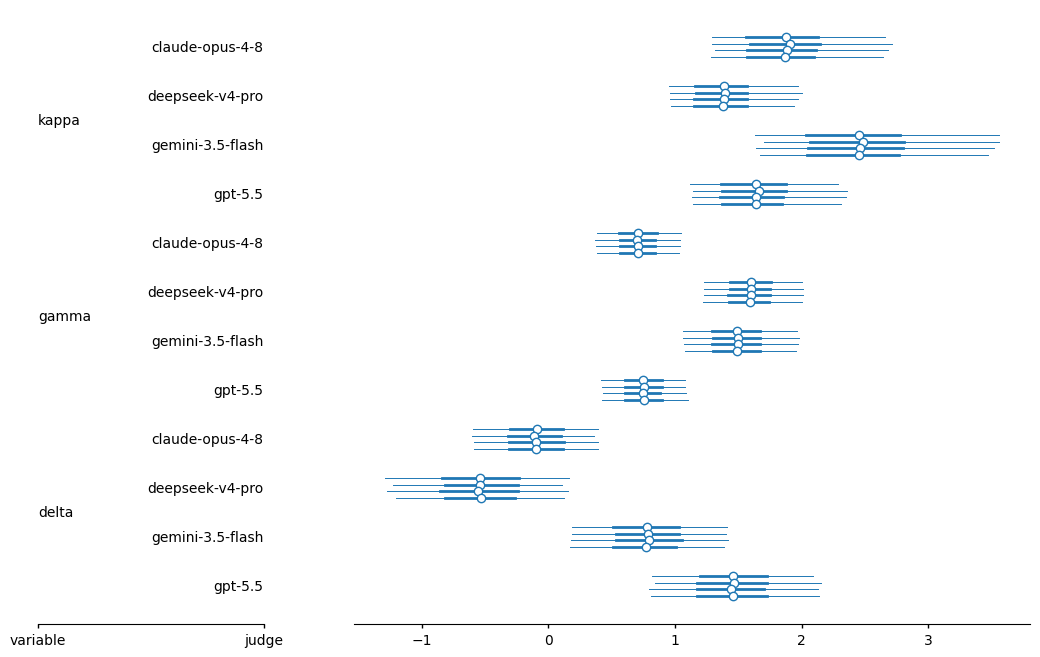

### `soundness` — strengths (beta)

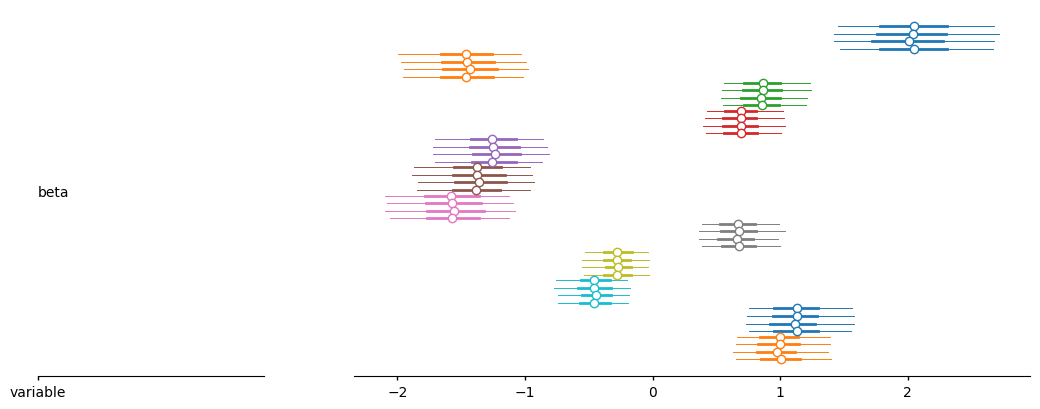

### `soundness` — judge effects

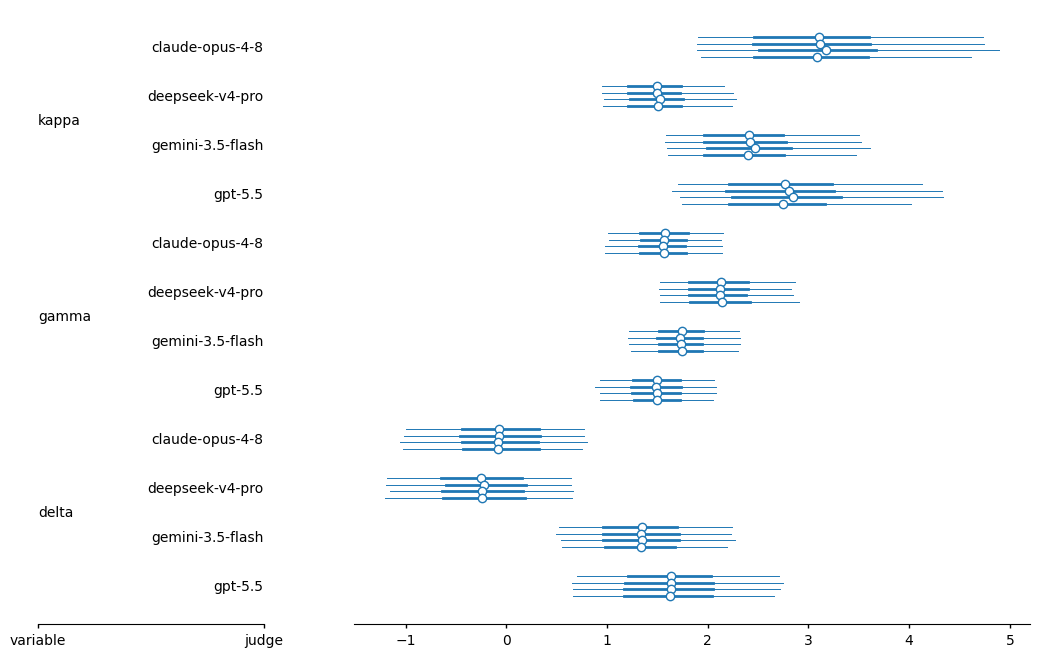

### `priors` — strengths (beta)

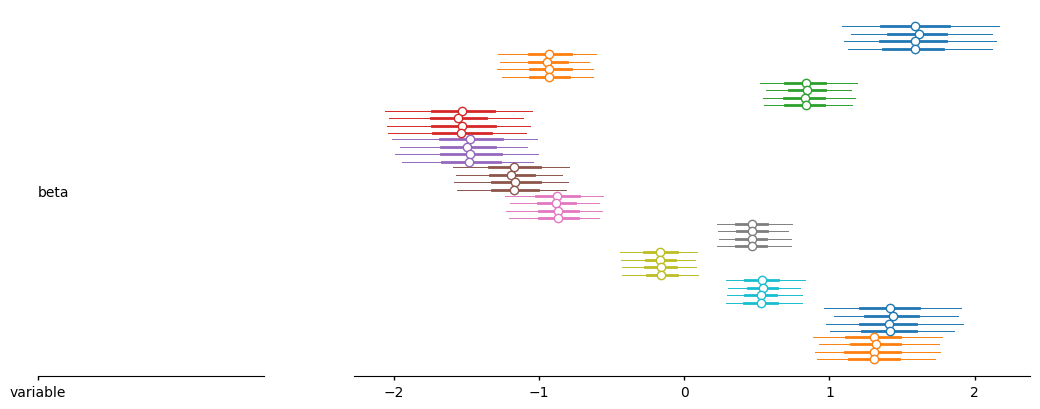

### `priors` — judge effects

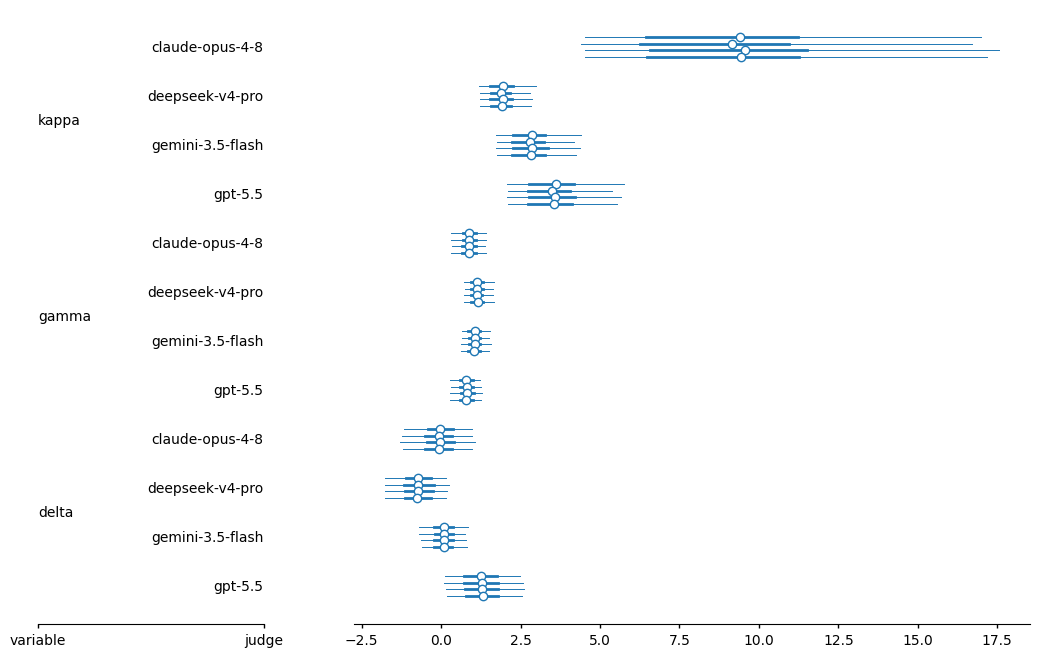

In [7]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — strengths (beta)"))
    az.plot_forest(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()
    display(Markdown(f"### `{t}` — judge effects"))
    az.plot_forest(traces[t], var_names=JUDGE_EFFECTS, backend="matplotlib")
    plt.show()


## Effective sample size (local)

ESS across the posterior's quantiles for the strengths. Bars/lines should sit well above the
rule-of-thumb floor (~400) everywhere, confirming the estimates aren't driven by a handful of
effectively independent draws.


### `overall` — ESS (beta)

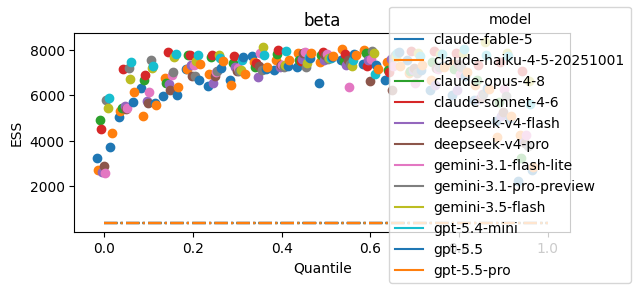

### `soundness` — ESS (beta)

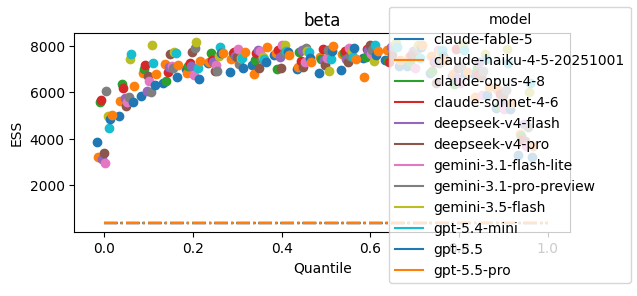

### `priors` — ESS (beta)

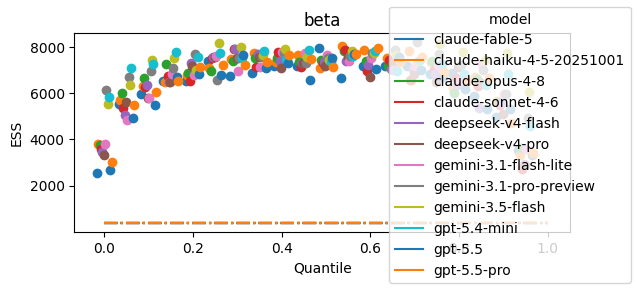

In [8]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — ESS (beta)"))
    az.plot_ess(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()
